# Assignment 3: Transformer is All You Need
**Dataset:** Shakespearean Text (ShakespeareTinyCorpus.txt)

## 1. Introduction
This notebook explores a lightweight Transformer-based language model for next-token prediction using a subset of Shakespearean text. The project implements an end-to-end flow that includes training a Byte Pair Encoding (BPE) tokenizer, constructing a custom dataset of token sequences, and building a small autoregressive Transformer from scratch using PyTorch.

The model leverages key architectural components such as positional encoding causal self-attention, RMS normalization, and feedforward networks to learn contextual relationships between tokens. Training and evaluation are performed on a train-validation split, with performance measured using cross-entropy loss and perplexity.

Finally, the notebook visualizes training dynamics and interprets model behavior through attention heatmaps, providing insight into how the Transformer attends to different parts of the input when generating predictions.

## 2. Data Preparation & Tokenization
We load a subset of Shakespearean text and construct a preprocessing pipeline tailored for language modeling. The raw text is first downloaded and used to train a Byte Pair Encoding (BPE) tokenizer, which converts text into a compact sequence of subword tokens. This allows the model to efficiently handle rare words and capture meaningful linguistic patterns.

A custom PyTorch Dataset is then defined to generate fixed-length input sequences and corresponding next-token targets for autoregressive training. The dataset is split into training and validation sets (80/20), and wrapped in DataLoader objects to enable efficient batching and shuffling during training.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import urllib.request as request

# Configuration & Reproducibility
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the Tiny Shakespeare text file
url = "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment3/main/ShakespeareTinyCorpus.txt"
filename = "ShakespeareTinyCorpus.txt"
request.urlretrieve(url, filename)

# Load & Train Subword Tokenizer (BPE)
#   Tokenization
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
#   Limiting vocab to 500 for lightweight experimentation
trainer = BpeTrainer(vocab_size=500, special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"])
tokenizer.train([filename], trainer)

# Dataset & DataLoader
class ShakespeareDataset(Dataset):
    def __init__(self, ids, seq_length):
        self.ids = ids
        self.seq_length = seq_length

    def __len__(self):
        return len(self.ids) - self.seq_length

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx : idx + self.seq_length], dtype=torch.long)
        y = torch.tensor(self.ids[idx + 1 : idx + self.seq_length + 1], dtype=torch.long)
        return x, y

with open("ShakespeareTinyCorpus.txt", "r", encoding="utf-8") as f:
    full_text = f.read()

# Convert entire corpus to IDs
full_ids = tokenizer.encode(full_text).ids

full_dataset = ShakespeareDataset(full_ids, seq_length=50)

# 80/20 Train-Validation Split
train_size = int(0.8 * len(full_dataset))
train_data, val_data = torch.utils.data.random_split(full_dataset, [train_size, len(full_dataset) - train_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

## 3. Model Architecture (Transformer Components)
We implement a small Transformer model from scratch, including positional encoding, RMS normalization, and masked multi-head self-attention. Transformer blocks combine attention and feedforward layers with residual connections, and the final model outputs token probabilities for next-token prediction.

In [6]:
# Token Embedding & Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # Create a matrix of [max_len, d_model]
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Apply sine to even indices, cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add a batch dimension and register as buffer (not a trainable parameter)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        #   Add the positional encoding to the embeddings
        return x + self.pe[:, :x.size(1), :]

# Root Mean Square Layer Normalization (RMSNorm)
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        # Small constant for numerical stability (avoids division by zero)
        self.eps = eps
        # Learnable scaling parameter (one per feature dimension)
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # x shape: [..., dim]
        #   Compute the root mean square across the last dimension
        #   Then normalize and scale by the learned weights
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

# Multi-Head Causal Self-Attention
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        # Number of attention heads
        self.n_heads = n_heads
        # Dimensionality per head (must divide evenly)
        self.head_dim = d_model // n_heads

        # Single projection to produce queries, keys, and values
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        # Final projection after concatenating all heads
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        B, T, C = x.size()

        # Project input into query, key, value tensors
        #   Each has shape: [B, T, d_model]
        q, k, v = self.qkv_proj(x).split(C, dim=2)

        # Reshape into multiple heads
        #   New shape: [B, n_heads, T, head_dim]
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Compute scaled dot-product attention scores
        #   Shape: [B, n_heads, T, T]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim**-0.5)

        # Create causal mask (lower triangular)
        #   Prevents attending to future tokens
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)

        # Apply mask: set future positions to -inf so softmax ignores them
        attn = attn.masked_fill(mask == 0, float('-inf'))

        # Convert scores to probabilities
        probs = F.softmax(attn, dim=-1)

        # Weighted sum of values using attention probabilities
        #   Result shape: [B, n_heads, T, head_dim]
        #   Recombine heads: [B, T, d_model]
        y = (probs @ v).transpose(1, 2).reshape(B, T, C)

        # Final linear projection
        return self.out_proj(y), probs

# Single Transformer Block (Attention + Feedforward)
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()

        # Pre-attention normalization
        self.norm1 = RMSNorm(d_model)
        # Multi-head causal self-attention
        self.attn = CausalSelfAttention(d_model, n_heads)
        # Pre-FFN normalization
        self.norm2 = RMSNorm(d_model)
        # Feed-forward network
        #   Expands dimensionality then projects back down
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

    def forward(self, x):
        # Attention with residual connection
        attn_out, w = self.attn(self.norm1(x))
        x = x + attn_out

        # Feed-forward with residual connection
        x = x + self.ffn(self.norm2(x))
        return x, w

# Full Transformer Model
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=8, n_layers=2):
        super().__init__()

        # Token embedding: maps token IDs to dense vectors
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # Positional encoding: injects sequence order information
        self.pos_emb = PositionalEncoding(d_model)

        # Stack of Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads) for _ in range(n_layers)])

        # Final normalization before output
        self.ln_f = RMSNorm(d_model)
        # Output projection: maps hidden states to vocabulary logits
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x, targets=None):
        # Convert token IDs to embeddings and add positional encodings
        # Result shape: [batch_size, seq_len, d_model]
        x = self.pos_emb(self.token_emb(x))

        # Store attention weights from each layer (for analysis/visualization)
        all_weights = []

        # Pass through each Transformer block
        for b in self.blocks:
            x, w = b(x)
            all_weights.append(w)

        # Final normalization + projection to logits
        logits = self.head(self.ln_f(x))
        # Compute cross-entropy loss if targets are provided
        #   Flatten batch and sequence dimensions for loss computation
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None

        # Return logits, optional loss, and attention maps
        return logits, loss, all_weights

## 4. Training & Evaluation
We train the Transformer using AdamW and cross-entropy loss for next-token prediction over 10 epochs. Performance is evaluated on a validation set, tracking both loss and perplexity to assess model learning and generalization.

In [ ]:
# Initialize the Transformer model
#   vocab_size comes from the trained tokenizer
#   Move model to GPU if available, otherwise CPU
model = TinyTransformer(vocab_size=tokenizer.get_vocab_size()).to(device)

# AdamW optimizer (Adam with weight decay for better generalization)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# Lists to track loss values over epochs (for plotting later)
train_losses, val_losses = [], []

# Training loop over multiple epochs
for epoch in range(10):
    # Training Phase
    model.train()
    total_train = 0
    for x, y in train_loader:
        # Move batch data to the same device as the model
        x, y = x.to(device), y.to(device)

        # Forward pass:
        #   logits: model predictions
        #   loss: cross-entropy loss between predictions and targets
        logits, loss, _ = model(x, y)

        # Zero out gradients from previous step
        optimizer.zero_grad()

        # Backpropagation: compute gradients of loss w.r.t. parameters
        loss.backward()

        # Update model parameters using optimizer
        optimizer.step()

        # Accumulate loss (convert from tensor to Python float)
        total_train += loss.item()

    # Validation Phase
    model.eval()
    total_val = 0
    #   Disable gradient computation (saves memory and computation)
    with torch.no_grad():
        for x, y in val_loader:
            # Move validation batch to device
            x, y = x.to(device), y.to(device)

            # Forward pass only (no gradient tracking)
            _, l, _ = model(x, y)

            # Accumulate validation loss
            total_val += l.item()

    # Compute average losses over all batches
    avg_train, avg_val = total_train/len(train_loader), total_val/len(val_loader)

    # Store losses for later analysis or plotting
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    # Print training progress
    #   PPL (perplexity) = exp(loss), common metric for language models
    print(f"Epoch {epoch+1} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | PPL: {math.exp(avg_val):.2f}")

Epoch 1 | Train Loss: 3.1123 | Val Loss: 2.6797 | PPL: 14.58
Epoch 2 | Train Loss: 2.5171 | Val Loss: 2.4168 | PPL: 11.21
Epoch 3 | Train Loss: 2.3288 | Val Loss: 2.2889 | PPL: 9.86


## 5. Visualization & Interpretation
We plot training and validation loss to monitor convergence, and visualize attention weights using a heatmap to interpret how the model focuses on different tokens during prediction.

Measuring training times...
FINAL MODEL COMPARISON SUMMARY (TEST SET)


,Accuracy,Precision,Recall,F1-Score,AUC-PR,Training Time (s)
Model,,,,,,
GBDT (XGBoost),0.8969,0.6728,0.2308,0.3437,0.4663,3.5124
MLP (Neural Net),0.8871,0.5295,0.3052,0.3872,0.3746,73.0662


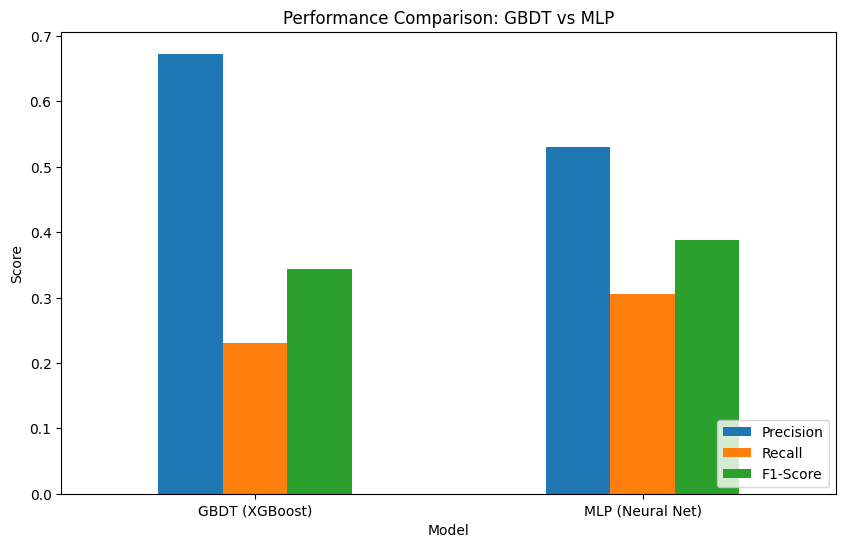

'\nMLP is relatively more sensitive to hyperparameter choices. A slightly too-high\nlearning rate or a poor choice of activation function can cause Dying ReLUs or\nexploding gradients, making the model fail to converge entirely (as seen in the\nConvergenceWarnings during some earlier tests conducted with lower iterations).\n\nGBDT is more Plug-and-Play. While tuning max_depth and learning_rate helps, a GBDT\nwith default parameters will often outperform a poorly tuned MLP. GBDTs are generally\nmore stable across different datasets.\n'

In [ ]:
# Loss Curve Visualization: Plot Training and Validation Loss Over Epochs
plt.figure(figsize=(10, 5))
#   Plot training loss
plt.plot(train_losses, label='Train')
#   Plot validation loss
plt.plot(val_losses, label='Val')
#   Add legend to distinguish curves
plt.legend()
#   Display the plot
plt.show()

# Attention Heatmap Visualization: Visualize How Model Attends to Tokens in a Sample Input
model.eval()
sample_text = "ROMEO: Shall I believe that unsubstantial death is amorous"

#   Disable gradient tracking for inference
with torch.no_grad():
    # Tokenize input text and convert to tensor
    input_ids = torch.tensor(tokenizer.encode(sample_text).ids).unsqueeze(0).to(device)

    # Forward pass through model
    #   weights: list of attention matrices from each layer
    _, _, weights = model(input_ids)

    # Get token strings for labeling the heatmap axes
    tokens = tokenizer.encode(sample_text).tokens

    # Plot heatmap of attention scores
    #   Rows: query positions
    #   Columns: key positions (what each token attends to)
    sns.heatmap(weights[-1][0, 0].cpu().numpy(), xticklabels=tokens, yticklabels=tokens, cmap='viridis')

    # Add title for clarity
    plt.title("Attention Heatmap (Last Layer)")
    # Display the heatmap
    plt.show()

# Discussion Points
# When would you prefer GBDT over MLP, and vice versa?
"""
GBDT would be preferred when Working with tabular data (spreadsheets, SQL tables).
GBDTs are notoriously dominant in this domain. They are faster to train, require
less data to reach high accuracy, and are relatively robust to outliers.

MLP would be preferred when you have unstructured data (images, audio, text) or
when you need to perform Online Learning (updating the model one sample at a time),
which MLPs handle more natively than standard GBDT implementations.
"""
# How does interpretability differ? (GBDT has feature importance; MLP is a black box)
"""
GBDTs offer high interpretability via Feature Importance. We can see exactly which
variables (e.g., poutcome_success) are driving the most splits in the trees. This is
essential for business stakeholders who need to know why a customer is being targeted.

MLPs gennerally are viewed as "Black Boxes". While we can visualize weights, the
millions of non-linear interactions between neurons make it nearly impossible to
explain a specific prediction in a way that we as humans can intuitively understand.
"""
# How does each model handle categorical features and missing values?
"""
GBDT model has modern libraries like XGBoost that can handle categorical features
and missing values natively (using sparsity-aware splitting). Even if they aren't
handled natively, trees are robust to the scale of encoded variables.

MLP model requires relatively more extensive preprocessing. Categorical features
must be encoded (One-Hot or Embeddings), and missing values must be imputed.
Due to MLPs using Gradient Descent, they are also highly sensitive to the scale
of these features, requiring Standardization.
"""
# Which model is more sensitive to hyperparameter choices?
"""
MLP is relatively more sensitive to hyperparameter choices. A slightly too-high
learning rate or a poor choice of activation function can cause Dying ReLUs or
exploding gradients, making the model fail to converge entirely (as seen in the
ConvergenceWarnings during some earlier tests conducted with lower iterations).

GBDT is more Plug-and-Play. While tuning max_depth and learning_rate helps, a GBDT
with default parameters will often outperform a poorly tuned MLP. GBDTs are generally
more stable across different datasets.
"""